<span style="color: #3498db;">**INF3721 : Apprentissage supervisée et non supervisée**</span>
<span style="color: red;">**TP1**</span>

**Les membres du GROUPE 3**

*   **NASSARAMADJI NASSAIRE 23**
*   **HAMIT ALI MAHAMAT 21T2884**
*   **MARIE**






<br><br><br>


**Etape 1 : Préparation du jeu de données**

**1 - téléchargement de données de tous les pays**

Au lieu de télécharger les données 217 pays manuellement , nous avons écrit un script permettant de télécharger le dossier zippé de tous les pays , chaque dossier contient :

*   Metadata_Indicator_API_
*   Metadata_Country_API_
*   Un fichier de préfixe API_

Puis le script les décompresse dans un seul dossier , nous avons :

*   **3 fichiers pour 217 pays**
*   Au total **651 fichiers** dans notre dossier **donnees_banque_mondiale**








In [2]:
import os
import requests
import zipfile
import io
import shutil
from google.colab import files

def telecharger_et_zipper_donnees():
    # 1. Création du dossier cible
    dossier_destination = "donnees_banque_mondiale"
    os.makedirs(dossier_destination, exist_ok=True)
    print(f"Dossier '{dossier_destination}' prêt.")

    # 2. Récupération des codes des 217 pays
    print("Récupération de la liste des pays via l'API...")
    url_pays = "https://api.worldbank.org/v2/country?format=json&per_page=300"
    reponse_pays = requests.get(url_pays)
    donnees_json = reponse_pays.json()

    # Filtrer les agrégats pour ne garder que les pays réels
    codes_pays = [pays['id'] for pays in donnees_json[1] if pays['region']['id'] != 'NA']
    print(f"{len(codes_pays)} pays identifiés. Début des téléchargements et de l'extraction...")

    # 3. Téléchargement et extraction (les 651 fichiers iront dans le dossier)
    for code_pays in codes_pays:
        url_archive = f"https://api.worldbank.org/v2/fr/country/{code_pays}?downloadformat=csv"
        try:
            reponse_telechargement = requests.get(url_archive)

            # Vérifier si le téléchargement a réussi (code HTTP 200 = succès)
            if reponse_telechargement.status_code == 200:
                # Lecture en mémoire et extraction des 3 CSV directement dans le dossier
                fichier_zip = zipfile.ZipFile(io.BytesIO(reponse_telechargement.content))
                fichier_zip.extractall(dossier_destination)
            else:
                print(f"❌ Erreur de téléchargement pour le pays {code_pays}")

        except Exception as erreur:
            print(f"❌ Échec pour {code_pays} : {erreur}")

    print("\n✅ Extraction terminée ! Les 651 fichiers (3 par pays) sont dans le dossier.")

    # 4. Compression du dossier en un fichier ZIP (méthode 100% Python)
    print("Compression du dossier en cours...")
    # shutil.make_archive(nom_archive_sortie, format, dossier_a_compresser)
    shutil.make_archive(dossier_destination, 'zip', dossier_destination)
    print(f"✅ Fichier '{dossier_destination}.zip' créé avec succès.")

    # 5. Déclenchement du téléchargement vers votre ordinateur
    print("Lancement du téléchargement...")
    files.download(f'{dossier_destination}.zip')

# Exécution du programme complet
telecharger_et_zipper_donnees()

Dossier 'donnees_banque_mondiale' prêt.
Récupération de la liste des pays via l'API...
217 pays identifiés. Début des téléchargements et de l'extraction...

✅ Extraction terminée ! Les 651 fichiers (3 par pays) sont dans le dossier.
Compression du dossier en cours...
✅ Fichier 'donnees_banque_mondiale.zip' créé avec succès.
Lancement du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<br><br><br>


**Etape 1 : Préparation du jeu de données**

**2 : Intégration de données**

Après avoir téléchager les données de tous les pays , nous procedons à les intégrer pour avoir un seul dataset de :

*   217 observations (lignes )
*   1517 attributs ( colonnes)

Pour cela, nous avons écrit un script qui permet:

*  d'extraire uniquement **l'année 2023**  de chaque **fichier API_**,

*  de transposer les lignes en colonnes,

* et d'y associer la classe **Income_Group** issue des fichiers **Metadata_Country_**



Nous avons besoin des bibliothèques suivantes et nous avons importer notre dossier contenant 651 fichiers  

En suite , nous bouclons sur chaque fichier **pays**

*  Nous extrayons l'année 2023,

*  et nous utilisons la fonction **pivot pour transformer les indicateurs (qui sont en lignes) en colonnes**,

*  afin qu'ils deviennent nos attributs.


En parallèle, nous récupérons la classe **(IncomeGroup)** dans le fichier de métadonnées associé

In [3]:
import os
import glob
import pandas as pd

dossier_source = "donnees_banque_mondiale"
fichiers_donnees = glob.glob(os.path.join(dossier_source, "API_*.csv"))

print(" Début de l'extraction des données...")

liste_tableaux_indicateurs = []
liste_tableaux_classes = []

for chemin in fichiers_donnees:
    # --- ÉTAPE A : Extraire les attributs ---
    df_api = pd.read_csv(chemin, skiprows=4)
    df_filtre = df_api[['Country Code', 'Indicator Code', '2023']]
    df_pivot = df_filtre.pivot(index='Country Code', columns='Indicator Code', values='2023').reset_index()
    liste_tableaux_indicateurs.append(df_pivot)

    # --- ÉTAPE B : Extraire la classe ---
    nom_fichier_meta = f"Metadata_Country_{os.path.basename(chemin)}"
    chemin_meta = os.path.join(dossier_source, nom_fichier_meta)

    if os.path.exists(chemin_meta):
        df_meta = pd.read_csv(chemin_meta)
        df_meta.columns = df_meta.columns.str.strip()

        if 'Country Code' in df_meta.columns and 'Income_Group' in df_meta.columns:
            df_meta_filtre = df_meta[['Country Code', 'Income_Group']].copy()
            df_meta_filtre = df_meta_filtre.dropna(subset=['Income_Group'])

            # On la nomme 'IncomeGroup' ici pour que ta cellule d'assemblage fonctionne parfaitement
            df_meta_filtre.rename(columns={'Income_Group': 'IncomeGroup'}, inplace=True)
            liste_tableaux_classes.append(df_meta_filtre)

print(f"✅ Extraction terminée ! {len(liste_tableaux_indicateurs)} pays traités.")

 Début de l'extraction des données...
✅ Extraction terminée ! 217 pays traités.


<br><br><br>


**Etape 1 : Préparation du jeu de données**

3 - **Concaténation et fusion**






  Maintenant que nous avons des listes contenant les données de chaque pays, nous les empilons (concat) pour créer deux grands tableaux : un pour les attributs et un pour les classes. Enfin, nous fusionnons (merge) ces deux tableaux en utilisant le code du pays comme clé de jointure





In [4]:
print("Assemblage des matrices en cours...")

# 1. Concaténer (empiler) les données de tous les pays
matrice_indicateurs = pd.concat(liste_tableaux_indicateurs, ignore_index=True)

# drop_duplicates assure de ne garder qu'une seule fois la classe par pays
matrice_classes = pd.concat(liste_tableaux_classes, ignore_index=True).drop_duplicates()

# 🔥 LE CORRECTIF : Nettoyer les espaces invisibles avant de renommer et fusionner
matrice_indicateurs['Country Code'] = matrice_indicateurs['Country Code'].astype(str).str.strip()
matrice_classes['Country Code'] = matrice_classes['Country Code'].astype(str).str.strip()

# 2. Renommer les colonnes pour respecter la nomenclature de l'énoncé
matrice_indicateurs.rename(columns={'Country Code': 'Country_code'}, inplace=True)
matrice_classes.rename(columns={'Country Code': 'Country_code', 'IncomeGroup': 'Income_Group'}, inplace=True)

# 3. Fusionner les attributs et la classe grâce à la clé "Country_code"
jeu_de_donnees_final = pd.merge(matrice_indicateurs, matrice_classes, on='Country_code', how='inner')

print("✅ Fusion terminée ! Le jeu de données global est assemblé.")

Assemblage des matrices en cours...
✅ Fusion terminée ! Le jeu de données global est assemblé.


<br><br><br>


**Etape 1 : Préparation du jeu de données**

**4 - Vérification et Sauvegarde**


Pour terminer, nous vérifions que les dimensions de notre matrice correspondent aux exigences du TP (217 pays et 1516 attributs + la classe). Ensuite, nous générons le fichier CSV final et le téléchargeons





In [5]:
from google.colab import files

# 1. Affichage des dimensions de la matrice
lignes, colonnes = jeu_de_donnees_final.shape
print(f"Dimensions du jeu de données : {lignes} observations, {colonnes} colonnes.")

# Afficher les 5 premières lignes pour vérifier visuellement
display(jeu_de_donnees_final.head())

# 2. Sauvegarder et déclencher le téléchargement automatique
nom_fichier_final = "dataset_group3.csv"
jeu_de_donnees_final.to_csv(nom_fichier_final, index=False)

print(f"Fichier généré. Lancement du téléchargement vers votre ordinateur...")
files.download(nom_fichier_final)

Dimensions du jeu de données : 217 observations, 1518 colonnes.


,Country_code,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,...,per_sa_allsa.cov_q5_tot,per_si_allsi.adq_pop_tot,per_si_allsi.ben_q1_tot,per_si_allsi.cov_pop_tot,per_si_allsi.cov_q1_tot,per_si_allsi.cov_q2_tot,per_si_allsi.cov_q3_tot,per_si_allsi.cov_q4_tot,per_si_allsi.cov_q5_tot,Income_Group
0,CAN,37.396970,132.840555,568750.0,6.471378,38151000.0,0.951789,4.340915,16033993.0,0.018660,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Revenu élevé
1,HRV,221.844456,169.019585,14860.0,26.554682,868000.0,0.224889,15.511079,539590.0,1.411723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Revenu élevé
2,BHS,NaN,NaN,130.0,1.298701,8000.0,0.020028,0.799201,82.0,0.299700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Revenu élevé
3,MNP,NaN,NaN,5.4,1.173913,80.0,0.001772,0.173913,NaN,0.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Revenu élevé
4,MYS,256.389410,2926.428663,85710.0,26.087354,784300.0,0.022328,2.387156,615072.0,22.705829,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Revenu intermédiaire, tranche supérieure"


Fichier généré. Lancement du téléchargement vers votre ordinateur...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<br><br><br>


**Etape 2 : Prétaitement du jeu de données**

**1 - Selection**

Dans notre dataset , nous avons constaté que :

*   Tous les pays **Ne publient pas leurs indicateurs ( 1500) chaque année** , donc en 2023, il y a des pays qui n'ont pas publié 1500 indicateurs

**Solution** : Pour résoudre ce problème , nous proposons de supprimer les indicateurs ayant plus **75% de NaN**

* La colonne **Country_code** est essentielle pour nous, les humains, mais elle ne sert à rien pour l'algorithme (un code pays n'explique pas mathématiquement la richesse d'un pays).

**Solution** : Nous allons définir Country_code comme l'index (le nom des lignes) de ton tableau de données au lieu d'une colonne classique.



** **texte en gras**Etape 2 : Prétaitement du jeu de données**

**2 - Gestion de valeurs manquantes NaN**

Le jeu de données contient énormement des valeurs manquantes , nous allons procéder de corriger comme suit :

*   A l'étape de la **sélection** ci-dessus, nous avons supprimé les colonnes ayant plus de 50% de valeurs manquantes, et pour les indicateurs nous allons remplacer les NaN par **la médiane**. Mais pourquoi nous choississons celle-ci plutôt que **la moyenne** ?


la médiane est souvent une bonne idée avec **les données économiques**, car cela évite que **la valeur soit faussée par des valeurs extrêmes** (comme le PIB des États-Unis ou de la Chine)


<br><br><br>


**Etape 2 : Prétaitement du jeu de données**

**3 - L'encodage**

L'encodage est l'une des étapes nécessaires pour le prétraitement de ondonnées . Dans notre cas, nous allons transformer la colonne de texte ( **Income_Group** ) **en valeurs numériques**  (0, 1, 2, 3) en utilisant un outil comme LabelEncoder de la bibliothèque Scikit-Learn, car les algorithmes ne comprennent que les mathématiques, ls ne savent pas lire **"Revenu élevé" ou "Faible revenu"**.



In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from google.colab import files # Ajout pour le téléchargement

# 1. Chargement du dataset
nom_fichier = "dataset_group3.csv"
df = pd.read_csv(nom_fichier)

print(f" Dimensions initiales : {df.shape[0]} pays et {df.shape[1]} colonnes.\n")

# --- ÉTAPE A : Mise à l'écart de l'identifiant ---
if 'Country_code' in df.columns:
    df.set_index('Country_code', inplace=True)
    print("✅ Identifiant 'Country_code' passé en index.")

# --- ÉTAPE B : Gestion des valeurs manquantes ---
# 1. Suppression des colonnes ayant plus de 75% de NaN
# Cela signifie qu'on exige au moins 25% de données valides (100% - 75%)
seuil_minimum_valeurs = len(df) * 0.25
df.dropna(thresh=seuil_minimum_valeurs, axis=1, inplace=True)

# 2. Remplacement des NaN restants par la médiane
colonnes_numeriques = df.select_dtypes(include=['float64', 'int64']).columns
df[colonnes_numeriques] = df[colonnes_numeriques].fillna(df[colonnes_numeriques].median())
print("✅ Nettoyage des valeurs manquantes (suppression > 75% et médiane) terminé.")

# --- ÉTAPE C : Encodage de la variable cible ---
if 'Income_Group' in df.columns:
    encodeur = LabelEncoder()
    # Transformation du texte en nombres
    df['Income_Group'] = encodeur.fit_transform(df['Income_Group'])

    # Affichage de la correspondance pour comprendre qui est 0, 1, 2...
    correspondance = dict(zip(encodeur.classes_, encodeur.transform(encodeur.classes_)))
    print(f"✅ Encodage de 'Income_Group' terminé. Correspondance : {correspondance}")

print(f"\n Nouvelles dimensions : {df.shape[0]} pays et {df.shape[1]} colonnes (hors index).")

# Aperçu du résultat
display(df.head())

# --- ÉTAPE D : Sauvegarde et Téléchargement ---
nom_fichier_nettoye = "dataset_group3_nettoye.csv"
# index=True est crucial ici pour ne pas perdre la colonne Country_code !
df.to_csv(nom_fichier_nettoye, index=True)

print("\n Lancement du téléchargement du dataset nettoyé vers votre ordinateur...")
files.download(nom_fichier_nettoye)

 Dimensions initiales : 217 pays et 1518 colonnes.

✅ Identifiant 'Country_code' passé en index.
✅ Nettoyage des valeurs manquantes (suppression > 75% et médiane) terminé.
✅ Encodage de 'Income_Group' terminé. Correspondance : {'Faible revenu': np.int64(0), 'Non classifié': np.int64(1), 'Revenu intermédiaire, tranche inférieure': np.int64(2), 'Revenu intermédiaire, tranche supérieure': np.int64(3), 'Revenu élevé': np.int64(4)}

 Nouvelles dimensions : 217 pays et 960 colonnes (hors index).


,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,AG.LND.FRST.K2,...,VA.NO.SRC,VA.PER.RNK,VA.PER.RNK.LOWER,VA.PER.RNK.UPPER,VA.STD.ERR,VC.IDP.NWDS,VC.IHR.PSRC.FE.P5,VC.IHR.PSRC.MA.P5,VC.IHR.PSRC.P5,Income_Group
Country_code,,,,,,,,,,,,,,,,,,,,,
CAN,37.396970,132.840555,568750.0,6.471378,38151000.0,0.951789,4.340915,16033993.0,0.018660,3468171.459,...,10.0,95.098038,89.705879,99.509804,0.135520,192000.0,1.036216,2.889999,1.979689,4
HRV,221.844456,169.019585,14860.0,26.554682,868000.0,0.224889,15.511079,539590.0,1.411723,19466.100,...,11.0,65.686272,60.294117,69.607841,0.104813,86.0,0.446135,0.904882,0.667347,4
BHS,90.781907,87.355750,130.0,1.298701,8000.0,0.020028,0.799201,82.0,0.299700,5098.600,...,5.0,74.019608,66.666664,84.803925,0.147869,5800.0,0.912517,2.599940,1.979689,4
MNP,90.781907,87.355750,5.4,1.173913,80.0,0.001772,0.173913,718310.0,0.195652,243.600,...,10.0,49.019608,40.686275,55.882355,0.125136,1100.0,0.912517,2.599940,1.979689,4
MYS,256.389410,2926.428663,85710.0,26.087354,784300.0,0.022328,2.387156,615072.0,22.705829,189635.900,...,11.0,50.980392,42.156864,56.862743,0.123358,206000.0,0.912517,2.599940,0.734492,3



 Lancement du téléchargement du dataset nettoyé vers votre ordinateur...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Etape 2 : Prétaitement du jeu de données**

**4 - La Normalisation**

C'est une étape obligatoire. Dans ton dataset, certains indicateurs sont des pourcentages (de 0 à 100), d'autres sont des surfaces en hectares, et d'autres sont des montants en milliards de dollars. Si tu ne mets pas tout à la même échelle, Si on ne met pas tout à la même échelle, l'algorithme va mathématiquement croire que la variable avec les plus grands nombres est la plus importante, ce qui faussera complètement les prédictions.

**Solution** : Nous allons utiliser l'outil MinMaxScaler de Scikit-Learn pour que toutes nos données explicatives soient strictement comparables (ramenées sur une échelle de 0 à 1). Nous excluons bien sûr la variable cible Income_Group de cette transformation.


In [7]:
from sklearn.preprocessing import MinMaxScaler
from google.colab import files

print(" Début de la normalisation des données...")

# 1. Initialisation de l'outil de mise à l'échelle
scaler = MinMaxScaler()

# 2. On isole les colonnes à normaliser (Toutes SAUF 'Income_Group')
colonnes_attributs = df.columns.drop('Income_Group')

# 3. Application de la transformation mathématique (entre 0 et 1)
df[colonnes_attributs] = scaler.fit_transform(df[colonnes_attributs])

print("✅ Normalisation terminée ! Toutes les variables explicatives sont maintenant entre 0 et 1.")

# Aperçu du résultat pour vérifier que les grands nombres ont disparu
display(df.head())

# --- ÉTAPE FINALE : Sauvegarde du dataset prêt pour le Machine Learning ---
nom_fichier_ml = "dataset_group3_normalise.csv"
df.to_csv(nom_fichier_ml, index=True)

print("\n Lancement du téléchargement du dataset final prêt pour l'entraînement...")
files.download(nom_fichier_ml)

 Début de la normalisation des données...
✅ Normalisation terminée ! Toutes les variables explicatives sont maintenant entre 0 et 1.


,AG.CON.FERT.PT.ZS,AG.CON.FERT.ZS,AG.LND.AGRI.K2,AG.LND.AGRI.ZS,AG.LND.ARBL.HA,AG.LND.ARBL.HA.PC,AG.LND.ARBL.ZS,AG.LND.CREL.HA,AG.LND.CROP.ZS,AG.LND.FRST.K2,...,VA.NO.SRC,VA.PER.RNK,VA.PER.RNK.LOWER,VA.PER.RNK.UPPER,VA.STD.ERR,VC.IDP.NWDS,VC.IHR.PSRC.FE.P5,VC.IHR.PSRC.MA.P5,VC.IHR.PSRC.P5,Income_Group
Country_code,,,,,,,,,,,,,,,,,,,,,
CAN,0.001845,0.045393,1.092877e-01,0.070049,2.479448e-01,0.652157,0.070816,1.552191e-01,0.000252,0.425380,...,0.692308,0.950980,0.933673,0.994975,0.165683,0.040833,0.083975,0.022605,0.029811,4
HRV,0.010993,0.057756,2.854850e-03,0.303492,5.640721e-03,0.154042,0.255213,5.223568e-03,0.023471,0.002388,...,0.769231,0.656863,0.627551,0.688442,0.000000,0.000018,0.032610,0.006710,0.009334,4
BHS,0.004493,0.029851,2.440371e-05,0.009923,5.153747e-05,0.013660,0.012350,7.938112e-07,0.004936,0.000625,...,0.307692,0.740196,0.693878,0.844221,0.232314,0.001233,0.073208,0.020283,0.029811,4
MNP,0.004493,0.029851,4.611725e-07,0.008472,6.499051e-08,0.001150,0.002027,6.953690e-03,0.003202,0.000030,...,0.692308,0.490196,0.423469,0.547739,0.109655,0.000234,0.073208,0.020283,0.029811,4
MYS,0.012706,1.000000,1.646904e-02,0.298060,5.096750e-03,0.015236,0.038564,5.954281e-03,0.378394,0.023259,...,0.769231,0.509804,0.438776,0.557789,0.100064,0.043811,0.073208,0.020283,0.010382,3



 Lancement du téléchargement du dataset final prêt pour l'entraînement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<br><br><br>


**Etape 3 : Analyse Explorative**


**1 - Statistiques descriptives**




A revoir

<br><br><br>


**Etape 4 : Séparation du jeu de données**

Afin d'entraîner notre modèle puis d'évaluer ses performances sur **des données qu'il n'a jamais vues**, nous devons diviser notre jeu de données en deux parties : 80% pour l'entraînement (Train) et 20% pour le test (Test).



Comment avons-nous obtenu la meilleure séparation possible ?
Pour garantir que nos deux sous-ensembles soient parfaitement représentatifs de la réalité, nous avons utilisé deux paramètres clés de la fonction train_test_split de Scikit-Learn :

* **La stratification (stratify=y)** : Ce paramètre force l'algorithme à conserver exactement la même proportion de chaque classe (Income_Group) dans le jeu d'entraînement et dans le jeu de test. Ainsi, on évite le risque de créer un jeu d'entraînement qui manquerait d'exemples pour une classe minoritaire.

* **La reproductibilité (random_state=42)** : Nous fixons la graine aléatoire pour que notre séparation, bien qu'aléatoire, donne le même résultat à chaque exécution du code, ce qui est indispensable pour comparer nos futurs modèles sur une base stable.


In [14]:
from sklearn.model_selection import train_test_split
import pandas as pd
from google.colab import files

print("✂️ 1. Séparation des données en cours...")

# On recrée X et y à partir de ton dataset df
X = df.drop('Income_Group', axis=1)
y = df['Income_Group']

# On génère X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("💾 2. Préparation des fichiers d'entraînement et de test...")

# Recombinaison des attributs (X) et de la cible (y)
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# Sauvegarde au format CSV
nom_fichier_train = "dataset_group3_train.csv"
nom_fichier_test = "dataset_group3_test.csv"

df_train.to_csv(nom_fichier_train, index=True)
df_test.to_csv(nom_fichier_test, index=True)

# Lancement des téléchargements
print(f"⬇️ Téléchargement de l'ensemble d'entraînement : {nom_fichier_train}...")
files.download(nom_fichier_train)

print(f"⬇️ Téléchargement de l'ensemble de test : {nom_fichier_test}...")
files.download(nom_fichier_test)

print("✅ Opération terminée avec succès !")

✂️ 1. Séparation des données en cours...
💾 2. Préparation des fichiers d'entraînement et de test...
⬇️ Téléchargement de l'ensemble d'entraînement : dataset_group3_train.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Téléchargement de l'ensemble de test : dataset_group3_test.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Opération terminée avec succès !


Enfin , pour prouver que nos deux ensembles (Train et Test) sont cohérents, nous comparons les moyennes et les écarts-types de leurs attributs. Si la séparation est bonne, les statistiques du jeu **d'entraînement** doivent être très proches de celles du jeu de **test**.


In [15]:
# 3. Vérification de la représentativité (Moyennes et Écarts-types)
print("Vérification de la représentativité des deux ensembles :")

# On calcule la moyenne globale et l'écart-type global de toutes les valeurs dans X_train et X_test
stats_comparaison = pd.DataFrame({
    'Statistique': ['Moyenne globale', 'Écart-type global'],
    'Jeu d\'Entraînement (Train)': [X_train.values.mean(), X_train.values.std()],
    'Jeu de Test (Test)': [X_test.values.mean(), X_test.values.std()]
})

display(stats_comparaison)

# Optionnel : Afficher les statistiques pour les 3 premières colonnes pour plus de détails
print("\n Détail pour les 3 premiers indicateurs :")
comparaison_detaillee = pd.DataFrame({
    'Attribut': X.columns[:3],
    'Moyenne Train': X_train.iloc[:, :3].mean().values,
    'Moyenne Test': X_test.iloc[:, :3].mean().values,
    'Écart-type Train': X_train.iloc[:, :3].std().values,
    'Écart-type Test': X_test.iloc[:, :3].std().values
})

display(comparaison_detaillee)

Vérification de la représentativité des deux ensembles :


,Statistique,Jeu d'Entraînement (Train),Jeu de Test (Test)
0,Moyenne globale,0.269190,0.270911
1,Écart-type global,0.293655,0.294854



 Détail pour les 3 premiers indicateurs :


,Attribut,Moyenne Train,Moyenne Test,Écart-type Train,Écart-type Test
0,AG.CON.FERT.PT.ZS,0.014303,0.006398,0.080617,0.007249
1,AG.CON.FERT.ZS,0.050148,0.044700,0.102408,0.057235
2,AG.LND.AGRI.K2,0.043909,0.037641,0.125173,0.078660


**Etape 5: Le modèle : K-NN**

Pour prédire le groupe de revenu d'un pays, Le modèle k-NN (k-Plus Proches Voisins) est un algorithme très intuitif. il va regarder les "k" pays du jeu d'entraînement qui lui ressemblent le plus (ses voisins).

* **1 - Définition de la mesure de distance entre les observations**

Nous avons choisi la **Distance Euclidienne** , pour que l'algorithme k-NN trouve les "voisins" d'un pays, il doit calculer la distance entre les observations.

**Justification :** Nos données sont composées de **variables numériques continues**.

De plus, grâce à notre étape précédente de normalisation (MinMaxScaler), tous nos indicateurs sont ramenés sur une échelle stricte de 0 à 1. La distance euclidienne est donc parfaite car aucune variable ne va dominer le calcul de la distance par rapport aux autres.

* **Le paramètre k**

Nous allons tester plusieurs valeurs impaires pour k (1, 3, 5, 7, 9, 11, etc.), car l'utilisation de nombres impairs permet d'éviter les cas d'égalité lors du "vote" des voisins pour déterminer la classe d'un pays.

L'objectif est de trouver le k optimal qui offre la meilleure exactitude (Accuracy), c'est-à-dire le plus haut pourcentage de pays bien classés.




Début de l'entraînement des modèles k-NN...

Tableau des exactitudes en fonction de k :


,Valeur de k,Exactitude,Pourcentage (%)
0,1,0.7500,75.00%
1,3,0.7500,75.00%
2,5,0.7500,75.00%
3,7,0.7273,72.73%
4,9,0.7500,75.00%
5,11,0.7273,72.73%
6,13,0.7500,75.00%
7,15,0.7045,70.45%
8,17,0.7045,70.45%
9,19,0.6818,68.18%


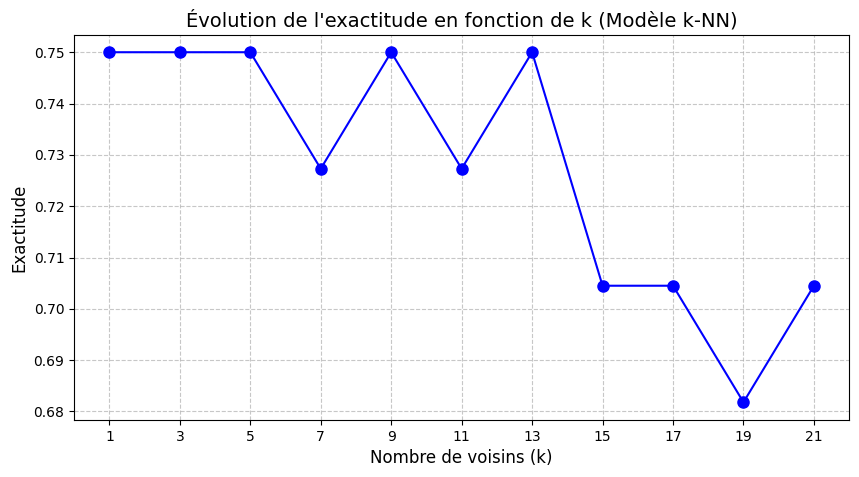


 Le meilleur résultat est obtenu pour k=1 avec une exactitude de 75.00%.


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

print("Début de l'entraînement des modèles k-NN...\n")

# Liste des valeurs de k à tester (uniquement des nombres impairs)
valeurs_k = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

# Liste pour stocker nos résultats
resultats_knn = []

# Boucle pour tester chaque valeur de k
for k in valeurs_k:
    # 1. Initialisation du modèle avec la distance euclidienne (p=2 équivaut à euclidienne dans sklearn)
    modele_knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # 2. Entraînement du modèle sur le jeu Train
    modele_knn.fit(X_train, y_train)

    # 3. Prédiction sur le jeu Test
    y_prediction = modele_knn.predict(X_test)

    # 4. Calcul de l'exactitude (Accuracy)
    exactitude = accuracy_score(y_test, y_prediction)

    # On sauvegarde le résultat (arrondi à 4 décimales pour la lisibilité)
    resultats_knn.append({
        'Valeur de k': k,
        'Exactitude': round(exactitude, 4),
        'Pourcentage (%)': f"{exactitude * 100:.2f}%"
    })

# Création du tableau récapitulatif (DataFrame)
df_resultats_knn = pd.DataFrame(resultats_knn)

print("Tableau des exactitudes en fonction de k :")
display(df_resultats_knn)

# --- BONUS VISUEL POUR TON RAPPORT ---
plt.figure(figsize=(10, 5))
plt.plot(df_resultats_knn['Valeur de k'], df_resultats_knn['Exactitude'],
         marker='o', linestyle='-', color='b', markersize=8)
plt.title("Évolution de l'exactitude en fonction de k (Modèle k-NN)", fontsize=14)
plt.xlabel("Nombre de voisins (k)", fontsize=12)
plt.ylabel("Exactitude", fontsize=12)
plt.xticks(valeurs_k)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Identification automatique du meilleur k
meilleur_k = df_resultats_knn.loc[df_resultats_knn['Exactitude'].idxmax()]
print(f"\n Le meilleur résultat est obtenu pour k={meilleur_k['Valeur de k']} avec une exactitude de {meilleur_k['Pourcentage (%)']}.")